## 2D Visual System Model   

Import utils

In [9]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
from lib.utils import *

1. Build net


In [26]:
#np.random.seed(seed=187)

#############################
#          Params           #
#############################

N_L0_E = 40000
N_L0_I = 40000  
N_L1_E = 40000
N_L1_I = 40000          
N_L2_E = 40000
N_L3_E = 3

# N_L0_E = 19600
# N_L0_I = 19600  
# N_L1_E = 62500
# N_L1_I = 62500          
# N_L2_E = 20000
# N_L3_E = 1

N = (N_L0_E+N_L0_I, N_L1_E+N_L1_I, N_L2_E, N_L3_E)
n = int(N_L0_E**(1/2))                   
sig = 0.00001
K = 1

sig_0_E = 0.015
sig_0_I = 0.045
sig_1_E = 0.015
sig_1_I = 0.030
sig_2_E = 0.040

sig_1_x_E = 0.06
sig_1_y_E = sig
sig_1_x_I = 0.06
sig_1_y_I = sig
sig_2_x_E = sig
sig_2_y_E = 0.10

sig_00 =  0.003          
sig_11 =  0.003
sig_22 =  0.003 

n_angles = 2
angles = np.linspace(0, 1, n_angles, endpoint=False)
probs = np.full(n_angles, 1/n_angles)

p_0 = 1

w_0_E =  1.0/(N_L0_E*np.pi*((sig_0_E)**2)*p_0)  
w_0_I =  -1.0/(N_L0_I*np.pi*((sig_0_I)**2)*p_0) 

w_1_E =  1.0/(N_L1_E*(1/len(angles))*np.pi*(sig_1_E**2)*p_0)  * 1.4    
w_1_I =  -1.0/(N_L1_I*(1/len(angles))*np.pi*(sig_1_I**2)*p_0) * 1.8

#w_2_E = 1

w_2_E   = 1.0/(N_L2_E*(1/len(angles))*np.pi*(sig_2_E**2)*p_0) * 3

w_00  =  1.0/(N_L0_E*np.pi*((sig_00)**2)*p_0) * 0.5
w_11  =  1.0/(N_L1_E*np.pi*((sig_11)**2)*p_0) * 0.5  


#############################
#        Create Net         #
#############################


# layer 0 
X, Y = np.meshgrid(np.linspace(0, 1, n), np.linspace(0, 1, n), indexing='xy')
coords = np.column_stack((X.ravel(), Y.ravel()))
xy_L0_E = coords

layer_lig_E = coords
layer_rec_E = coords.copy()

xy_L0_I = np.random.rand(N_L0_I, 2)
layer_lig_I = xy_L0_I + sig * np.random.randn(N_L0_I, 2)
layer_rec_I = xy_L0_I + sig * np.random.randn(N_L0_I, 2)

layer_lig_L0_combined = np.vstack((layer_lig_E, layer_lig_I))
layer_rec_L0_combined = np.vstack((layer_rec_E, layer_rec_I))

net = [[layer_lig_L0_combined, layer_rec_L0_combined]]

# layer 1

# ext
xy_E    = np.random.rand(N_L1_E, 2)
theta_E = np.random.choice(angles, size=N_L1_E, p=probs)*np.pi

#xy_E[:,0] =  xy_E[:,1] = 0.5

xy_lig_E = xy_E + sig * np.random.randn(N_L1_E, 2)
xy_rec_E = xy_E + sig * np.random.randn(N_L1_E, 2)
th_lig_E = theta_E + sig * np.random.randn(N_L1_E)
th_rec_E = theta_E + sig * np.random.randn(N_L1_E)

noise_theta = warp_coords(np.random.randn(N_L1_E, 2), th_rec_E, sig_1_x_E, sig_1_y_E)
layer_rec_xy_E = xy_lig_E + noise_theta

layer_lig_3d_E = np.column_stack((xy_lig_E, th_lig_E))
layer_rec_3d_E = np.column_stack((layer_rec_xy_E, th_rec_E))

# inh
# xy_I    = np.random.rand(N_L1_I, 2)
# theta_I = np.random.choice(angles, size=N_L1_I, p=probs)*np.pi

# xy_lig_I = xy_I + sig * np.random.randn(N_L1_I, 2)
# xy_rec_I = xy_I + sig * np.random.randn(N_L1_I, 2)
# th_lig_I = theta_I + sig * np.random.randn(N_L1_I)
# th_rec_I = theta_I + sig * np.random.randn(N_L1_I)

# noise_theta = warp_coords(np.random.randn(N_L1_I, 2), th_rec_I, sig_1_x_I, sig_1_y_I)
# layer_rec_xy_I = xy_lig_I + noise_theta

# layer_lig_3d_I = np.column_stack((xy_lig_I, th_lig_I))
# layer_rec_3d_I = np.column_stack((layer_rec_xy_I, th_rec_I))

# layer_lig_3d_combined = np.vstack((layer_lig_3d_E, layer_lig_3d_I))
# layer_rec_3d_combined = np.vstack((layer_rec_3d_E, layer_rec_3d_I))

# net.append([layer_lig_3d_combined, layer_rec_3d_combined])

xy_I    = np.random.rand(N_L1_I, 2)
theta_I = np.random.choice(angles, size=N_L1_I, p=probs)*np.pi

xy_lig_I = xy_I + sig * np.random.randn(N_L1_I, 2)
xy_rec_I = xy_I + sig * np.random.randn(N_L1_I, 2)
th_lig_I = theta_I + sig * np.random.randn(N_L1_I)
th_rec_I = theta_I + sig * np.random.randn(N_L1_I)

#noise_theta = warp_coords(np.random.randn(N_L1_I, 2), th_rec_I, sig_1_x_I, sig_1_y_I)
#layer_rec_xy_I = xy_lig_I + noise_theta

layer_lig_3d_I = np.column_stack((xy_lig_I, th_lig_I))
layer_rec_3d_I = np.column_stack((xy_rec_I, th_rec_I))

layer_lig_3d_combined = np.vstack((layer_lig_3d_E, layer_lig_3d_I))
layer_rec_3d_combined = np.vstack((layer_rec_3d_E, layer_rec_3d_I))

net.append([layer_lig_3d_combined, layer_rec_3d_combined])

# layer 2

xy_L2_E    = np.random.rand(N_L2_E, 2)
theta_L2_E = np.random.choice(angles, size=N_L2_E, p=probs)*np.pi

#xy_L2_E[:,0] =  xy_L2_E[:,1] = 0.5

xy_lig_L2_E = xy_L2_E + sig * np.random.randn(N_L2_E, 2)
xy_rec_L2_E = xy_L2_E + sig * np.random.randn(N_L2_E, 2)
th_lig_L2_E = theta_L2_E + sig * np.random.randn(N_L2_E)
th_rec_L2_E = theta_L2_E + sig * np.random.randn(N_L2_E)

noise_theta = warp_coords(np.random.randn(N_L2_E, 2), th_rec_L2_E, sig_2_x_E, sig_2_y_E)
layer_rec_xy_L2_E = xy_lig_L2_E + noise_theta

layer_lig = np.column_stack((xy_lig_L2_E, th_lig_L2_E))
layer_rec = np.column_stack((layer_rec_xy_L2_E, th_rec_L2_E))

net.append([layer_lig, layer_rec])

# z = np.random.rand(N_L2_E, 3)
# z[:,2] = np.random.choice(angles, size=N_L2_E, p=probs)*np.pi


# #z[:,0] =  z[:,1] = 0.5
 
# layer_lig = z + (sig * np.random.randn(N_L2_E, 3))
# layer_rec = z + (sig * np.random.randn(N_L2_E, 3))

# net.append([layer_lig, layer_rec])


# layer 3

z = np.random.rand(N_L3_E, 3)
z[:,2] = np.random.choice(angles, size=N_L3_E, p=probs)*np.pi

z[:,0] =  z[:,1] = 0.5

z[0,2] = 0*np.pi
z[1,2] = 0.5*np.pi
z[2,2] = 0*np.pi
z[0:2, 0] = z[0:2, 1] = 0.5
z[2, 0] = z[2, 1] = 0.75

layer_lig = z + (sig * np.random.randn(N_L3_E, 3))
layer_rec = z + (sig * np.random.randn(N_L3_E, 3))

net.append([layer_lig, layer_rec])


#############################
#  Create Connectivity      #
#############################

l_vals_L0_E = net[0][0][0:N_L0_E]
l_vals_L0_I = net[0][0][N_L0_E:]
r_vals_L0_E = net[0][1][0:N_L0_E]
r_vals_L0_I = net[0][1][N_L0_E:]
l_vals_L1_E = net[1][0][0:N_L1_E, :2]
l_vals_L1_I = net[1][0][N_L1_E:, :2]
l_vals_L1_I_3d = net[1][0][N_L1_E:]
r_vals_L1_E = net[1][1][0:N_L1_E]
r_vals_L1_I = net[1][1][N_L1_E:]
l_vals_L2   = net[2][0]
l_vals_L2_E    = net[2][0]    
r_vals_L2_E    = net[2][1]     
l_vals_L3      = net[3][0]                 

kappa = 50

#L0->L1
prob_00 = compute_prob_2d_sparse(r_vals_L0_E, l_vals_L0_I, sig_00)          
B_00 = sample_bernoulli_sparse(prob_00, K)
W_00 = (w_00 * B_00).tocsr()

prob_11 = compute_prob_2d_sparse(r_vals_L1_E, l_vals_L1_I_3d, sig_11, kappa=kappa)   
B_11 = sample_bernoulli_sparse(prob_11, K)
W_11 = (w_11 * B_11).tocsr()

B_L0E_L1E = sample_bernoulli_sparse(compute_prob_2d_sparse(r_vals_L0_E, l_vals_L1_E, sig_0_E), K)
B_L0I_L1E = sample_bernoulli_sparse(compute_prob_2d_sparse(r_vals_L0_I, l_vals_L1_E, sig_0_I), K)
W_0_E_block = (w_0_E * B_L0E_L1E).tocsr()
W_0_I_block = (w_0_I * B_L0I_L1E).tocsr()

W_0_E = W_0_E_block.tocsr()
W_0_I = (W_00 @ W_0_I_block).tocsr()

#L1->L2
B_L1E_L2 = sample_bernoulli_sparse(compute_prob_2d_sparse(r_vals_L1_E, l_vals_L2, sig_1_E, kappa=kappa), K)
B_L1I_L2 = sample_bernoulli_sparse(compute_prob_2d_sparse(r_vals_L1_I, l_vals_L2, sig_1_I, kappa=kappa), K)
W_1_E_block = (w_1_E * B_L1E_L2).tocsc()
W_1_I_block = (w_1_I * B_L1I_L2).tocsc()

W_1_E = W_1_E_block.tocsc()
W_1_I = (W_11 @ W_1_I_block).tocsc()

#L2->L3
B_L2E_L3 = sample_bernoulli_sparse(compute_prob_2d_sparse(r_vals_L2_E, l_vals_L3, sig_2_E, kappa=kappa), K)
W_2_E_block = (w_2_E * B_L2E_L3).tocsc()
W_2_E = W_2_E_block.tocsc()




2. Analyze net


 &emsp; 2.1. Analyze On-Center Cells<br>

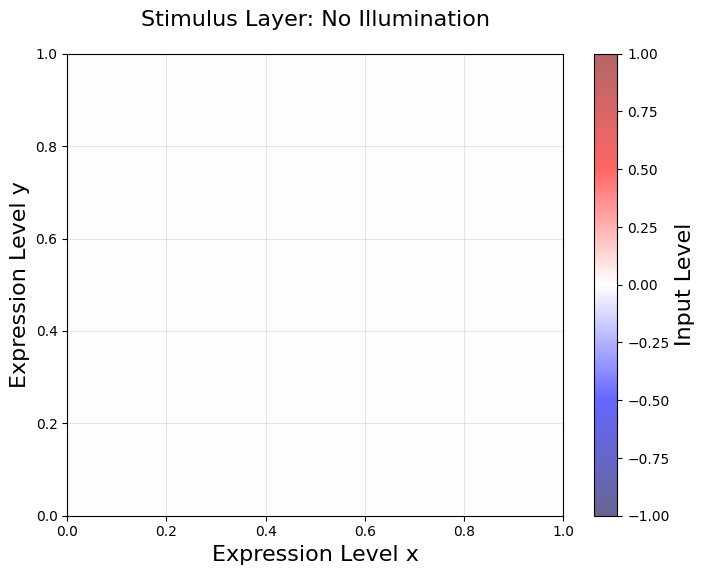

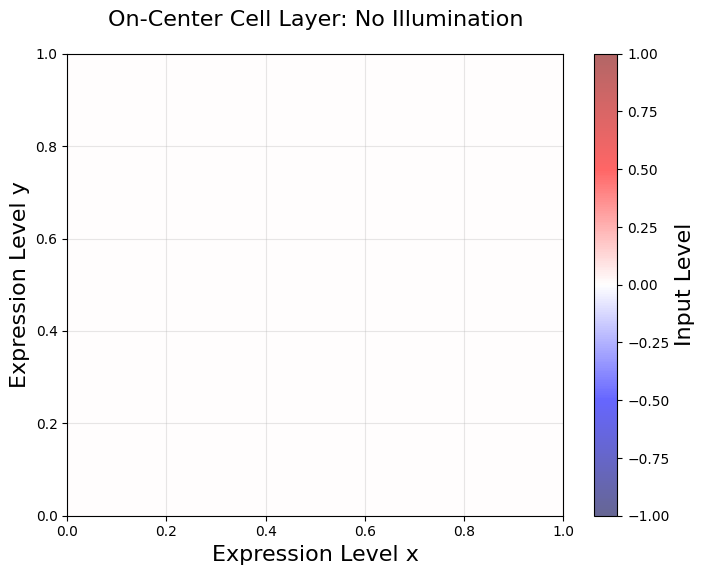

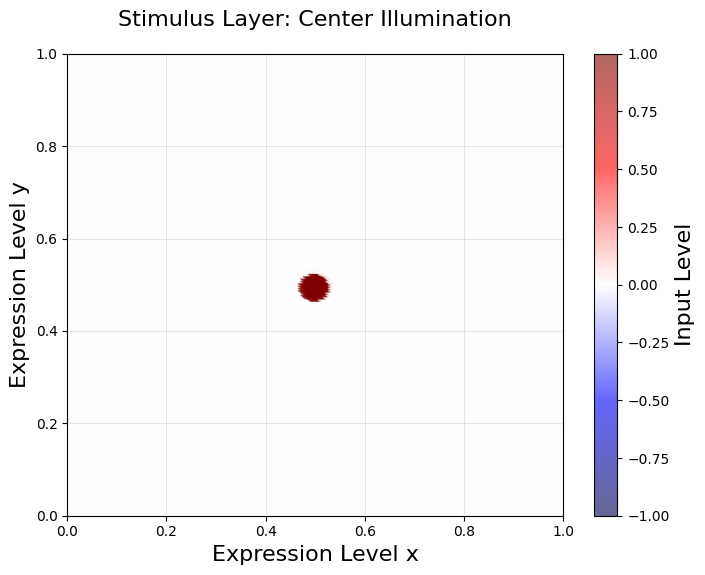

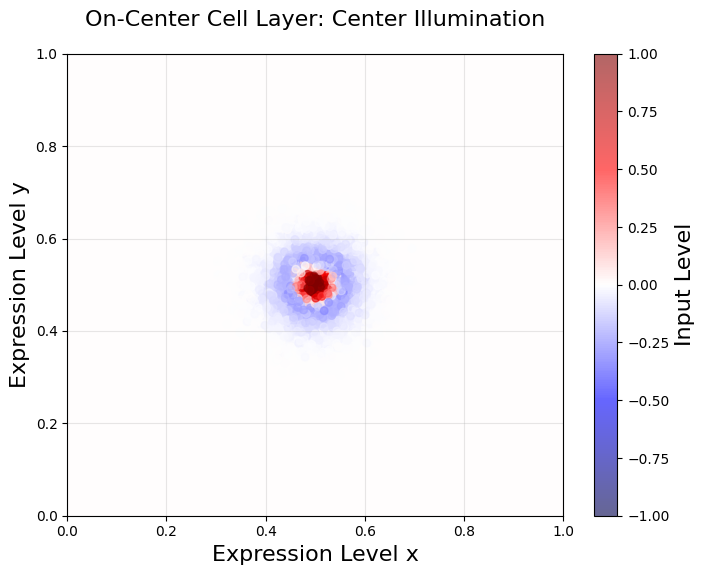

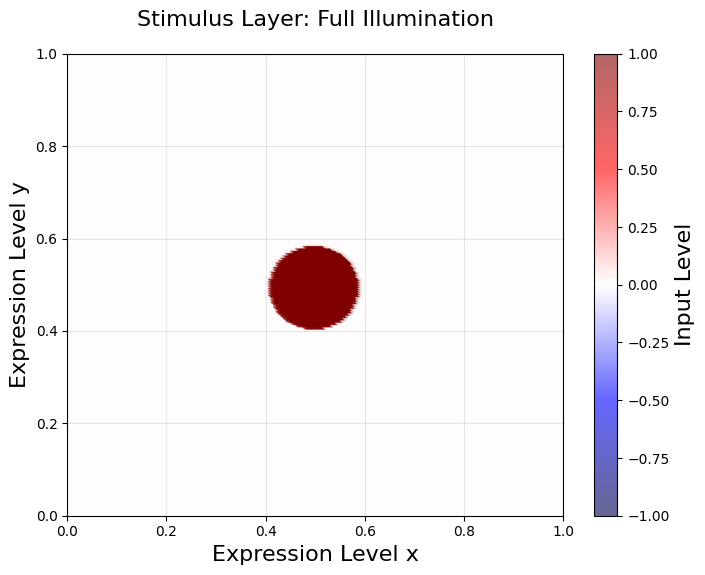

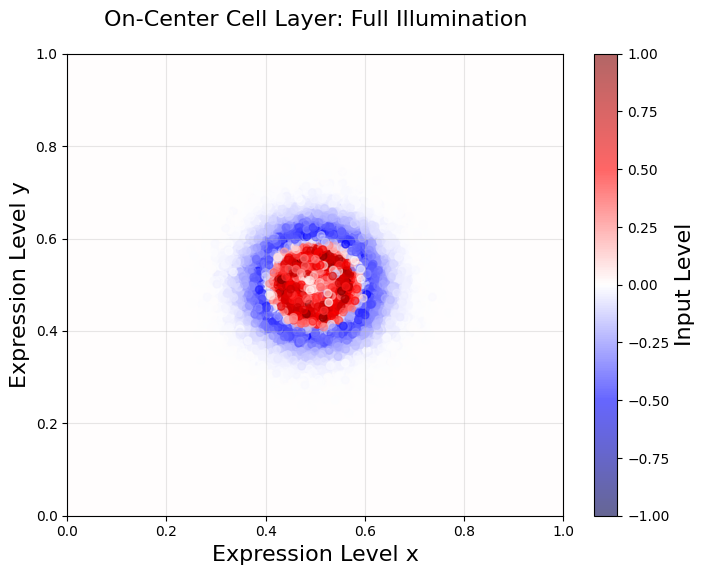

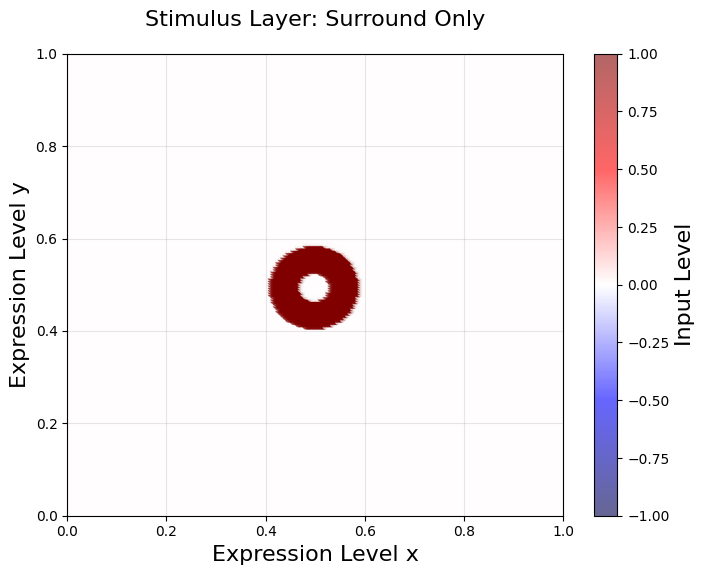

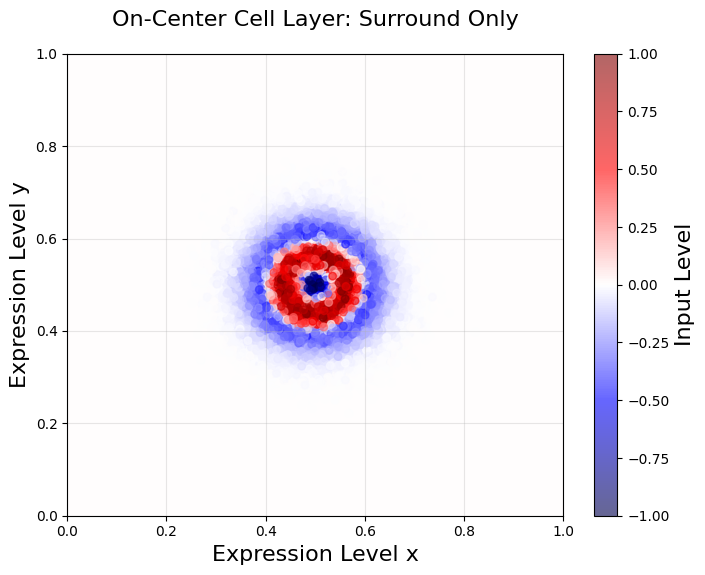

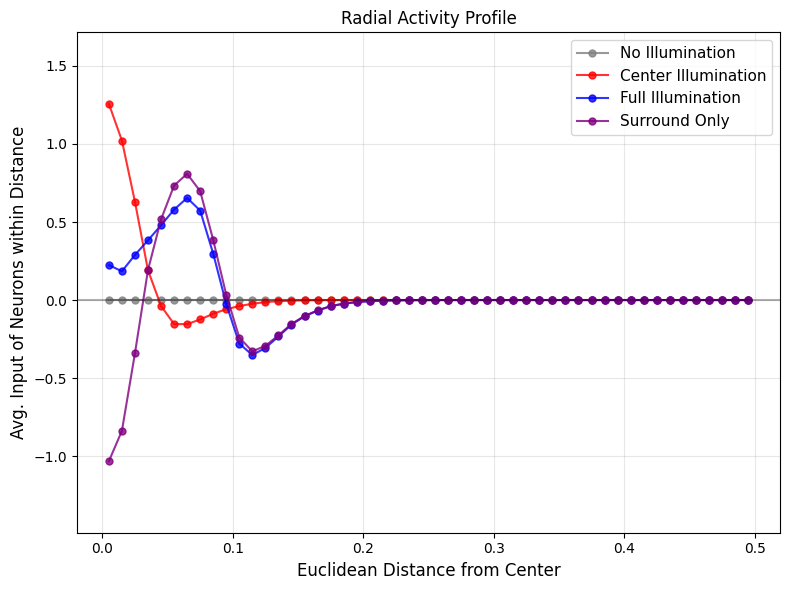

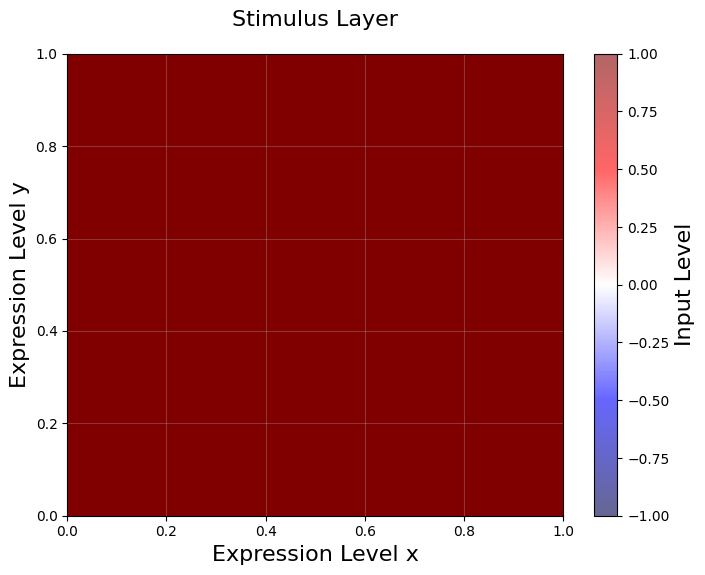

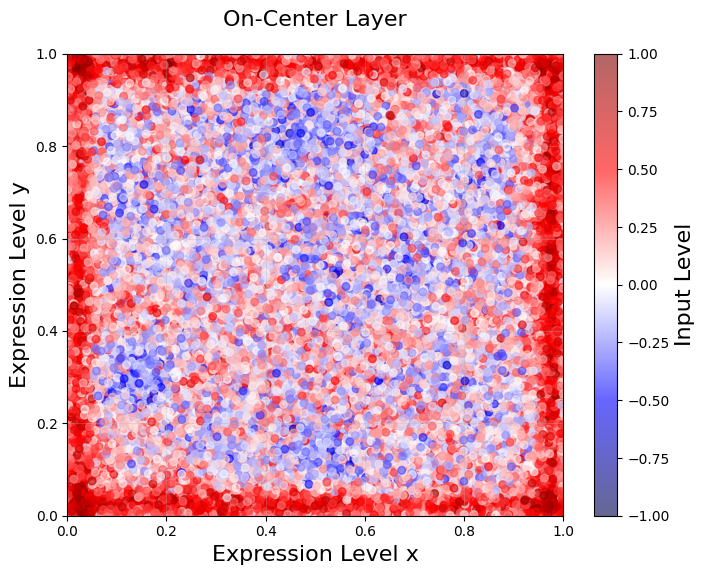

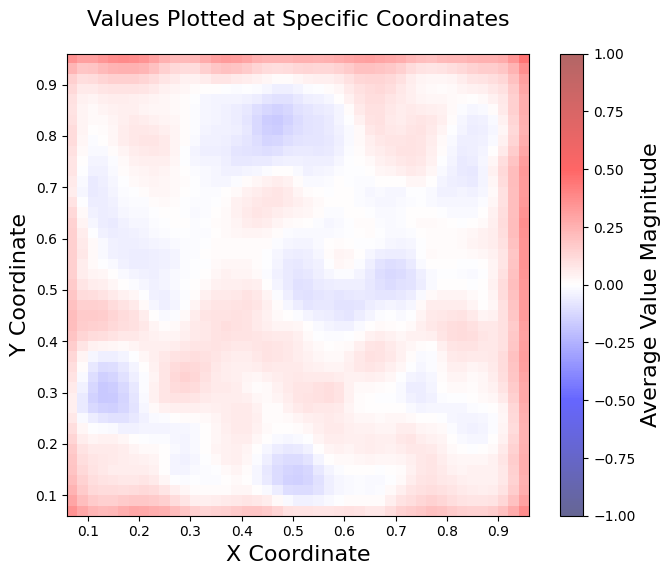

In [27]:
#############################
#   Stimulus Conditions     #
#############################

dot_center = (0.5, 0.5)

mask_center = apply_stimulus(2 * sig_0_E, coords=r_vals_L0_E, center=dot_center)
mask_full   = apply_stimulus(2 * sig_0_I, coords=r_vals_L0_E, center=dot_center)

conditions = [
    ('No Illumination',     np.zeros_like(mask_center)),
    ('Center Illumination', mask_center),
    ('Full Illumination',   mask_full),
    ('Surround Only',       mask_full - mask_center),
]

W_0 = W_0_E + W_0_I

x_0, y_0 = l_vals_L0_E[:, 0], l_vals_L0_E[:, 1]
x_1, y_1 = l_vals_L1_E[:, 0], l_vals_L1_E[:, 1]

for name, A_0 in conditions:
    A_1 = np.asarray(ReLU(A_0) @ W_0).ravel()

    plot_stim_act(A_0, x_0, y_0,
                  title=f'Stimulus Layer: {name}',
                  xlabel='Expression Level x', ylabel='Expression Level y',
                  cbar_label='Input Level')

    plot_stim_act(A_1, x_1, y_1,
                  title=f'On-Center Cell Layer: {name}',
                  xlabel='Expression Level x', ylabel='Expression Level y',
                  cbar_label='Input Level')

#############################
#   Plot Condition Radial   #
#############################


plot_standalone_radial_activity(conditions, W_0_E + W_0_I, l_vals_L1_E,
                               num_bins=50, max_radius=0.5)

#############################
#      Full Stimulus        #
#############################

dot_radius = 100 * sig_0_E
dot_center = (0.5, 0.5)

A_0 = apply_stimulus(dot_radius, coords=r_vals_L0_E, center=dot_center)
A_1 = np.asarray(ReLU(A_0) @ (W_0_E + W_0_I)).ravel()

crop = 2 * sig_0_I

A_0 = apply_stimulus(dot_radius, coords=r_vals_L0_E, center=dot_center)

plot_stim_act(A_0, l_vals_L0_E[:, 0], l_vals_L0_E[:, 1],
              title='Stimulus Layer',
              xlabel='Expression Level x', ylabel='Expression Level y',
              cbar_label='Input Level')

plot_stim_act(A_1, l_vals_L1_E[:, 0], l_vals_L1_E[:, 1],
              title='On-Center Layer',
              xlabel='Expression Level x', ylabel='Expression Level y',
              cbar_label='Input Level')


plot_stim_act_image(A_1, l_vals_L1_E[:, 0], l_vals_L1_E[:, 1], sigma=1, zoom=1.1)

Averaging over 20 L1 neurons within 0.01


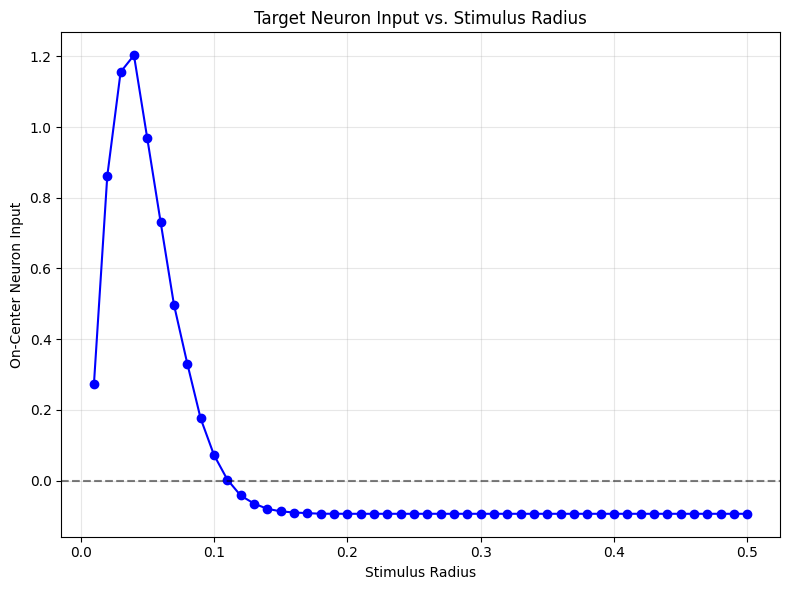

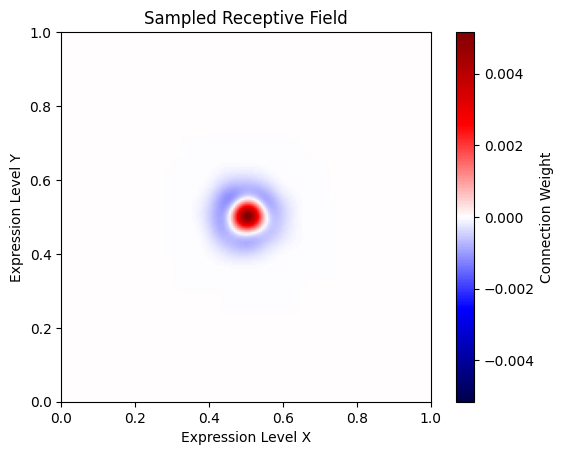

In [17]:
#############################
#        Radial Plot        #
#############################


target_x, target_y = 0.50, 0.50
center_radius = 0.01

spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
center_idx = np.argmin(spatial_dist)
center_ids = np.where(spatial_dist <= center_radius)[0]
print(f'Averaging over {len(center_ids)} L1 neurons within {center_radius}')

stim_dist = np.sqrt((r_vals_L0_E[:, 0] - target_x)**2 +
                    (r_vals_L0_E[:, 1] - target_y)**2)

W_0 = (W_0_E + W_0_I).tocsr()

radii = np.linspace(0.01, 0.5, 50)
activities = []

for r in radii:
    I_0_r = (stim_dist <= r).astype(float)
    I_1_r = np.asarray(W_0.T @ ReLU(I_0_r)).ravel()
    activities.append(I_1_r[center_ids].mean())

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(radii, activities, marker='o', linestyle='-', color='b')
ax.set_title('Target Neuron Input vs. Stimulus Radius')
ax.set_xlabel('Stimulus Radius')
ax.set_ylabel('On-Center Neuron Input')
ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#############################
#       Analytical RF       #
#############################

W_0_csc = W_0.tocsc()
W_eff = W_0_csc[:, center_idx].toarray().ravel()

true_rf = W_eff.reshape(n, n)
true_rf = gaussian_filter(true_rf, sigma=5)    

vmax_true = np.max(np.abs(true_rf))
fig, ax = plt.subplots()
im0 = ax.imshow(true_rf[::-1, :], cmap='seismic', vmin=-vmax_true, vmax=vmax_true, extent=[0, 1, 0, 1])
ax.set_title('Sampled Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')
plt.colorbar(im0, ax=ax, label='Connection Weight')
plt.show()

#############################
#        Find RWA RF        #
#############################

# n_frames = 50000
# stim = np.random.randn(n_frames, N_L0_E)

# W_0_csc = W_0.tocsc()
# W_eff = W_0_csc[:, center_idx].toarray().ravel()

# acts = stim @ W_eff

# rwa_flat = (acts @ stim) / n_frames

# rwa_2d = rwa_flat.reshape(n, n)
# rwa_2d = gaussian_filter(rwa_2d, sigma=3)

# vmax_rwa = np.max(np.abs(rwa_2d))

# fig, ax = plt.subplots()
# im0 = ax.imshow(rwa_2d[::-1, :], cmap='seismic', vmin=-vmax_rwa, vmax=vmax_rwa, extent=[0, 1, 0, 1])
# ax.set_title('RWA Receptive Field')
# ax.set_xlabel('Expression Level X')
# ax.set_ylabel('Expression Level Y')

# plt.colorbar(im0, ax=ax, label='Connection Weight')

# plt.show()

 &emsp; 2.2. Analyze Simple Cells<br>

Index: 38447
Location: x=0.498, y=0.502
Preferred Orientation: 0.0°



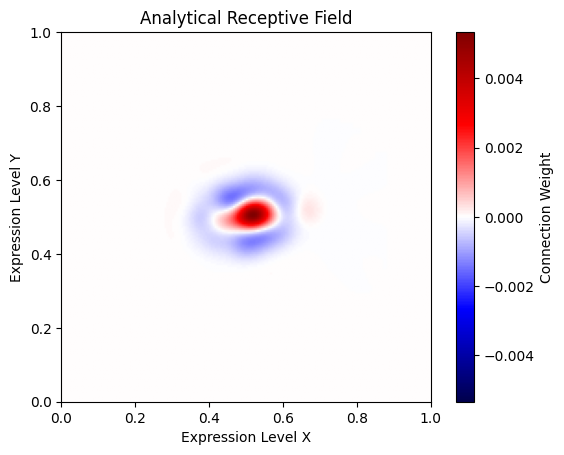

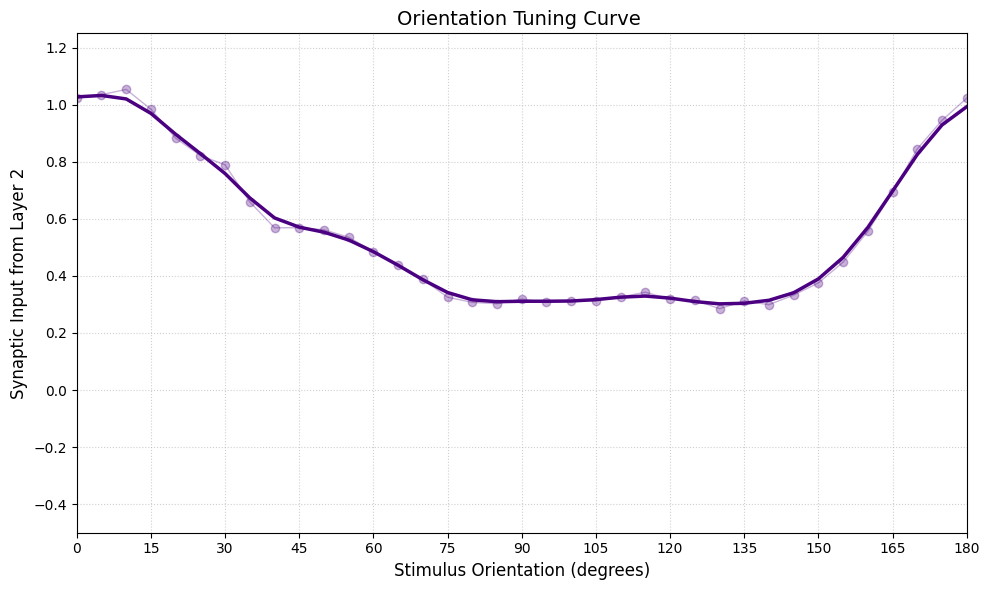

L1 index: 38447
Location: x=0.498, y=0.502
Preferred Orientation: 0.0°

spont_L2 = 0.005311
sf =   2.00 cyc/unit   L2 F1/F0 =  1.982
sf =   2.35 cyc/unit   L2 F1/F0 =  1.886
sf =   2.76 cyc/unit   L2 F1/F0 =  1.826
sf =   3.24 cyc/unit   L2 F1/F0 =  1.785
sf =   3.80 cyc/unit   L2 F1/F0 =  1.751
sf =   4.46 cyc/unit   L2 F1/F0 =  1.727
sf =   5.24 cyc/unit   L2 F1/F0 =  1.705
sf =   6.15 cyc/unit   L2 F1/F0 =  1.680
sf =   7.22 cyc/unit   L2 F1/F0 =  1.660
sf =   8.47 cyc/unit   L2 F1/F0 =  1.647
sf =   9.94 cyc/unit   L2 F1/F0 =  1.640
sf =  11.67 cyc/unit   L2 F1/F0 =  1.634
sf =  13.71 cyc/unit   L2 F1/F0 =  1.603
sf =  16.09 cyc/unit   L2 F1/F0 =  1.545
sf =  18.89 cyc/unit   L2 F1/F0 =  1.566
sf =  22.17 cyc/unit   L2 F1/F0 =  1.460
sf =  26.03 cyc/unit   L2 F1/F0 =  1.605
sf =  30.56 cyc/unit   L2 F1/F0 =  2.024
sf =  35.88 cyc/unit   L2 F1/F0 =  2.532
sf =  42.12 cyc/unit   L2 F1/F0 =  0.865
sf =  49.45 cyc/unit   L2 F1/F0 =  1.316
sf =  58.05 cyc/unit   L2 F1/F0 =  1.960
sf =  

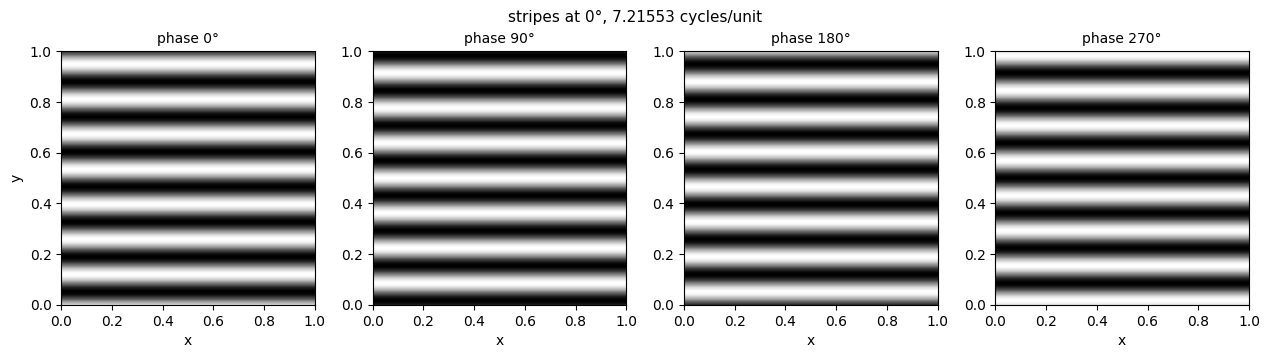

In [18]:
#############################
#       Analytical RF       #
#############################

coords = [0.5,0.5]
target_x, target_y = 0.50, 0.50
target_theta = np.radians(0)

spatial_dist = np.sqrt((l_vals_L2_E[:, 0] - target_x)**2 + (l_vals_L2_E[:, 1] - target_y)**2)
angular_dist = np.abs(l_vals_L2_E[:, 2] - target_theta)

target_idx = np.argmin(spatial_dist + angular_dist) 
center_idx = target_idx

print(f"Index: {target_idx}")
print(f"Location: x={l_vals_L2_E[target_idx, 0]:.3f}, y={l_vals_L2_E[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L2_E[target_idx, 2]):.1f}°\n")

W0_full = (W_0_E + W_0_I).tocsr()

w1_col_E = W_1_E[:, center_idx]     
w1_col_I = W_1_I[:, center_idx]     

rf_via_E = 1 * np.asarray((W0_full @ w1_col_E).todense()).ravel()
rf_via_I = 1 * np.asarray((W0_full @ w1_col_I).todense()).ravel()
rf_total = rf_via_E + rf_via_I

true_rf = rf_total.reshape(n,n)
true_rf = gaussian_filter(true_rf, sigma=5)

vmax_true = np.max(np.abs(true_rf))
fig, ax = plt.subplots()
im0 = ax.imshow(true_rf[::-1, :], cmap='seismic', vmin=-vmax_true, vmax=vmax_true, extent=[0, 1, 0, 1])
ax.set_title('Analytical Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')
plt.colorbar(im0, ax=ax, label='Connection Weight')
plt.show()

#############################
#  Orientation Tuning Curve #
#############################

angles_deg = np.arange(0, 181, 5)
cell_inputs = []

for deg in angles_deg:
    theta_stim = np.radians(deg)
    
    stim_indices, _, _ = get_indices_in_line(
        xy_L0_E, theta_stim, thickness=sig_0_E*2, length=0.25, cx=target_x, cy=target_y
    )
    
    mask = np.zeros(int(N[0]/2))
    mask[stim_indices] = 1

    A_0 = mask
    A_1 = ReLU(A_0) @ W_0_E +  ReLU(A_0) @ W_0_I
    A_2 = ReLU(A_1) @ W_1_E +  ReLU(A_1) @ W_1_I
    target_cell_input = A_2[target_idx]
    
    cell_inputs.append(target_cell_input)

cell_inputs = np.asarray(cell_inputs)
cell_inputs_smooth = gaussian_filter1d(cell_inputs, sigma=1.0, mode='nearest')

plt.figure(figsize=(10, 6))
plt.plot(angles_deg, cell_inputs, marker='o', linestyle='-', color='indigo',
         linewidth=1, alpha=0.3)
plt.plot(angles_deg, cell_inputs_smooth, linestyle='-', color='indigo', linewidth=2.5)

plt.title('Orientation Tuning Curve ', fontsize=14)
plt.xlabel('Stimulus Orientation (degrees)', fontsize=12)
plt.ylabel('Synaptic Input from Layer 2', fontsize=12)
plt.xticks(np.arange(0, 181, 15))
plt.xlim(0, 180)
plt.ylim(-0.5,1.25)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#############################
#      F1 / F0 Ratio        #
#############################

n_phase = 32
phases = np.arange(n_phase) * 2 * np.pi / n_phase
sfs = np.logspace(np.log10(2), np.log10(80), 24)
contrast = 1.0
best_sf, best_peak, best_L1 = None, -np.inf, None


print(f"L1 index: {target_idx}")
print(f"Location: x={l_vals_L2_E[target_idx, 0]:.3f}, y={l_vals_L2_E[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L2_E[target_idx, 2]):.1f}\u00b0\n")

A_0 = np.full(N_L0_E, 0.5)
A_1 = ReLU(np.asarray(A_0 @ W_0_E + A_0 @ W_0_I).ravel())
A_2 = ReLU(np.asarray(A_1 @ W_1_E + A_1 @ W_1_I).ravel())
spont_L2 = A_2[target_idx]
print(f"spont_L2 = {spont_L2:.6f}")

for sf in sfs:
    resp_L2 = np.zeros(n_phase)
    for i, phase in enumerate(phases):
        A_0 = grating(xy_L0_E, target_theta, sf, phase, contrast=contrast)
        A_1 = ReLU(np.asarray(A_0 @ W_0_E + A_0 @ W_0_I).ravel())
        A_2 = ReLU(np.asarray(A_1 @ W_1_E + A_1 @ W_1_I).ravel())
        resp_L2[i] = A_2[target_idx]

    L2 = f1_f0(resp_L2, spont_L2)
    print(f"sf = {sf:6.2f} cyc/unit   L2 F1/F0 = {L2['ratio']:6.3f}")

    if L2['peak'] > best_peak:
        best_sf, best_peak, best_L1 = sf, L2['peak'], L2
    


kind = 'SIMPLE' if best_L1['ratio'] > 1 else 'COMPLEX'
print(f"\nAt the preferred spatial frequency ({best_sf:.2f} cycles/unit):\n")
print(f"  L2:  F0 = {best_L1['F0']:.4f}   F1 = {best_L1['F1']:.4f}   "
      f"F2 = {best_L1['F2']:.4f}   F1/F0 = {best_L1['ratio']:.3f}   -> {kind}")


plot_grating(xy_L0_E, n, target_theta, best_sf, zoom=1, contrast=contrast)
plt.show()

Index: 38447
Location: x=0.498, y=0.502
Preferred Orientation: 0.0°



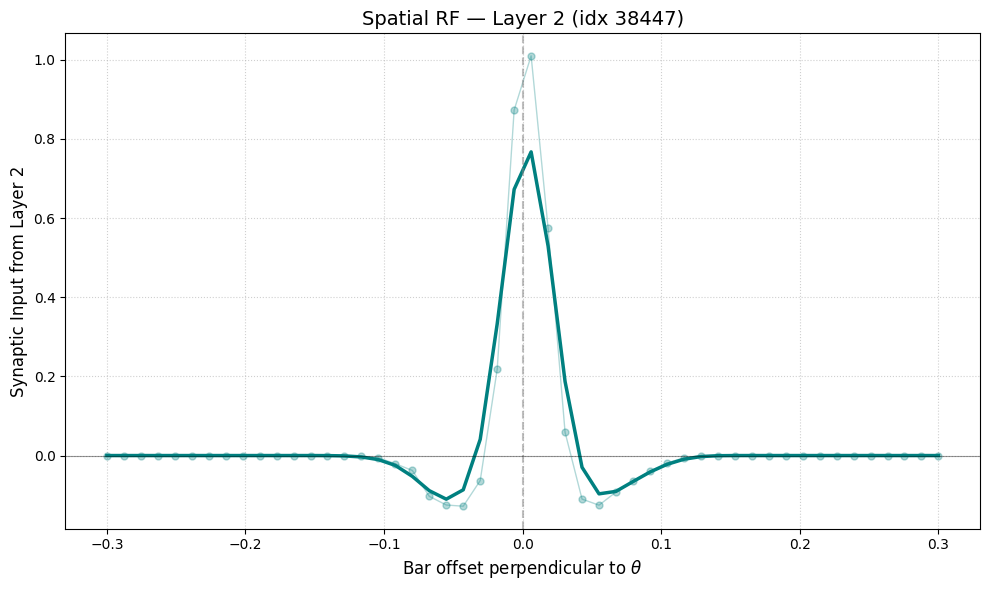

In [19]:
#############################
#   Bar Sweep RF: Layer 2   #
#############################

W_0 = (W_0_E + W_0_I).tocsr()
W_1 = (W_1_E + W_1_I).tocsr()

fwd = lambda a, W: np.asarray(a @ W).ravel()

target_x, target_y = 0.50, 0.50
theta_stim = np.radians(0)

ang_pen  = np.abs(np.mod(l_vals_L2[:, 2] - theta_stim + np.pi/2, np.pi) - np.pi/2)
same_ori = np.where(ang_pen < np.pi/4)[0]
spatial_dist = np.linalg.norm(l_vals_L2[same_ori, :2] - [target_x, target_y], axis=1)

target_idx = same_ori[np.argmin(spatial_dist)]

print(f"Index: {target_idx}")
print(f"Location: x={l_vals_L2[target_idx, 0]:.3f}, y={l_vals_L2[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L2[target_idx, 2]):.1f}°\n")


n_steps   = 50
offsets   = np.linspace(-0.30, 0.30, n_steps)
thickness = sig_0_E * 2
length    = 1.0

n_ref = len(get_indices_in_line(xy_L0_E, theta_stim, thickness=thickness,
                               length=length, cx=target_x, cy=target_y)[0])

cell_inputs = []

for d in offsets:
    cx = target_x - d * np.sin(theta_stim)
    cy = target_y + d * np.cos(theta_stim)

    stim_indices, _, _ = get_indices_in_line(
        xy_L0_E, theta_stim, thickness=thickness, length=length, cx=cx, cy=cy
    )

    mask = np.zeros(N_L0_E)
    mask[stim_indices] = 1
    mask *= n_ref / max(mask.sum(), 1)

    A_0 = mask
    A_1 = fwd(ReLU(A_0), W_0)
    A_2 = fwd(ReLU(A_1), W_1)
    target_cell_input = A_2[target_idx]

    cell_inputs.append(target_cell_input)

cell_inputs = np.asarray(cell_inputs)
cell_inputs_smooth = gaussian_filter1d(cell_inputs, sigma=1.0, mode='nearest')

plt.figure(figsize=(10, 6))
plt.plot(offsets, cell_inputs, marker='o', ms=5, linestyle='-', color='teal',
         linewidth=1, alpha=0.3)
plt.plot(offsets, cell_inputs_smooth, linestyle='-', color='teal', linewidth=2.5)

plt.title(f'Spatial RF — Layer 2 (idx {target_idx})', fontsize=14)
plt.xlabel('Bar offset perpendicular to $\\theta$', fontsize=12)
plt.ylabel('Synaptic Input from Layer 2', fontsize=12)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(0, color='k', linewidth=0.8, alpha=0.4)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

 &emsp; 2.3. Analyze Complex Cells<br>

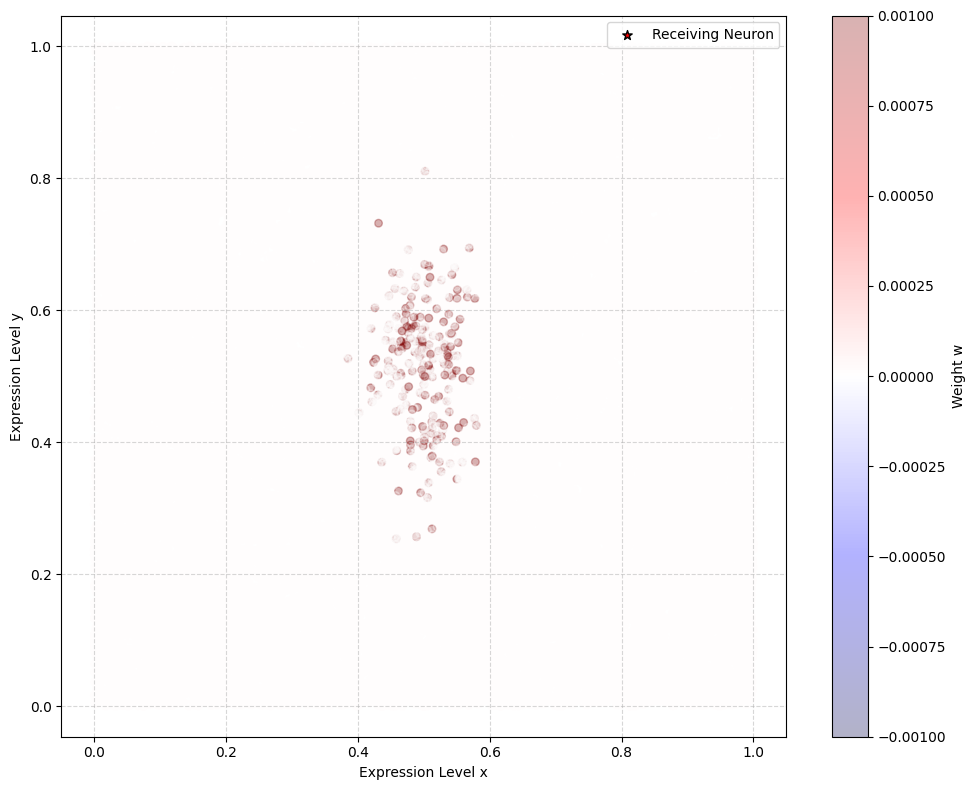

In [29]:
target_x, target_y = 0.50, 0.50
spatial_dist = np.sqrt((l_vals_L3[:, 0] - target_x)**2 + (l_vals_L3[:, 1] - target_y)**2)
center_idx = np.argmin(spatial_dist)

plot_spatial_prob_mask(
     receiver_idx=center_idx,
     prob_mask=W_2_E_block,
     sender_coords=l_vals_L2_E,
     receiver_coords=l_vals_L3,
     title='',
     vmin=-0.001,
     vmax=0.001)

spont_L3 = 0.226372

sf =   2.00 cyc/unit   L3 F1/F0 =  1.314
sf =   2.35 cyc/unit   L3 F1/F0 =  0.711
sf =   2.76 cyc/unit   L3 F1/F0 =  0.390
sf =   3.24 cyc/unit   L3 F1/F0 =  0.237
sf =   3.80 cyc/unit   L3 F1/F0 =  0.131
sf =   4.46 cyc/unit   L3 F1/F0 =  0.029
sf =   5.24 cyc/unit   L3 F1/F0 =  0.052
sf =   6.15 cyc/unit   L3 F1/F0 =  0.108
sf =   7.22 cyc/unit   L3 F1/F0 =  0.160
sf =   8.47 cyc/unit   L3 F1/F0 =  0.052
sf =   9.94 cyc/unit   L3 F1/F0 =  0.035
sf =  11.67 cyc/unit   L3 F1/F0 =  0.092
sf =  13.71 cyc/unit   L3 F1/F0 =  0.045
sf =  16.09 cyc/unit   L3 F1/F0 =  0.020
sf =  18.89 cyc/unit   L3 F1/F0 =  0.304
sf =  22.17 cyc/unit   L3 F1/F0 =  0.257
sf =  26.03 cyc/unit   L3 F1/F0 =  0.460
sf =  30.56 cyc/unit   L3 F1/F0 =  0.070
sf =  35.88 cyc/unit   L3 F1/F0 =  0.440
sf =  42.12 cyc/unit   L3 F1/F0 =  0.588
sf =  49.45 cyc/unit   L3 F1/F0 =  0.815
sf =  58.05 cyc/unit   L3 F1/F0 =  0.887
sf =  68.15 cyc/unit   L3 F1/F0 =  0.557
sf =  80.00 cyc/unit   L3 F1/F0 =  0

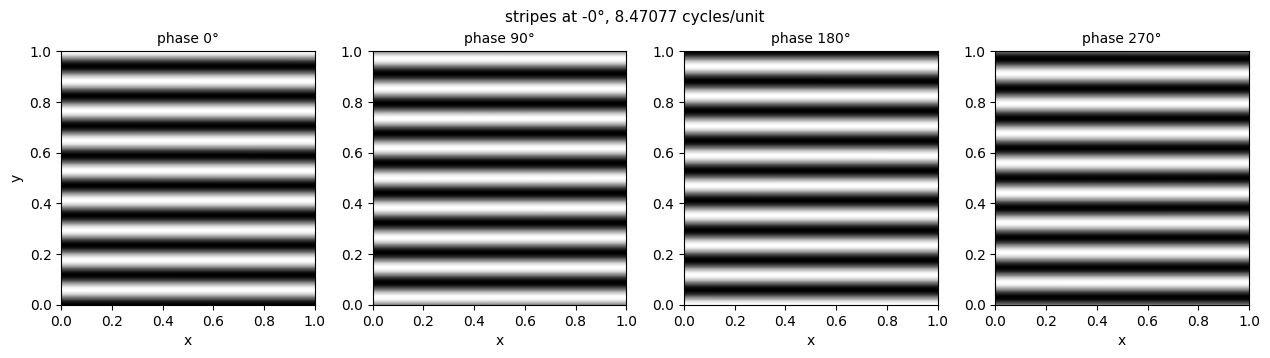

In [31]:
#############################
#         F1 / F0: L3       #
#############################

n_phase = 32
phases = np.arange(n_phase) * 2 * np.pi / n_phase
sfs = np.logspace(np.log10(2), np.log10(80), 24)
contrast = 1.0

l3_idx       = 0
target_theta = l_vals_L3[l3_idx, 2]


def propagate(A_0):
    A_1 = ReLU(np.asarray(A_0 @ W_0_E + A_0 @ W_0_I).ravel())
    A_2 = ReLU(np.asarray(A_1 @ W_1_E + A_1 @ W_1_I).ravel())
    return ReLU(np.asarray(A_2 @ W_2_E).ravel())


spont_L3 = propagate(np.full(N_L0_E, 0.5))[l3_idx]
print(f"spont_L3 = {spont_L3:.6f}\n")

records = []

for sf in sfs:
    resp_L3 = np.zeros(n_phase)
    for i, phase in enumerate(phases):
        resp_L3[i] = propagate(grating(xy_L0_E, target_theta, sf, phase,
                                       contrast=contrast))[l3_idx]

    L3 = f1_f0(resp_L3, spont_L3)
    records.append(dict(sf=sf, L3=L3, r3=resp_L3))

    print(f"sf = {sf:6.2f} cyc/unit   L3 F1/F0 = {L3['ratio']:6.3f}")

    if L3['peak'] > best_peak:
        best_sf, best_peak, best_L1 = sf, L3['peak'], L3

best = max(records, key=lambda rec: rec['L3']['peak'])
d    = best['L3']
kind = 'SIMPLE' if d['ratio'] > 1 else 'COMPLEX'
print(f"\n  L3 @ {best['sf']:.2f} cyc/unit:  F0 = {d['F0']:.4f}  F1 = {d['F1']:.4f}  "
      f"F2 = {d['F2']:.4f}  F1/F0 = {d['ratio']:.3f}  -> {kind}")

plot_grating(xy_L0_E, n, target_theta, best_sf, zoom=1, contrast=contrast)
plt.show()

Index: 0
Location: x=0.500, y=0.500
Preferred Orientation: -0.0°



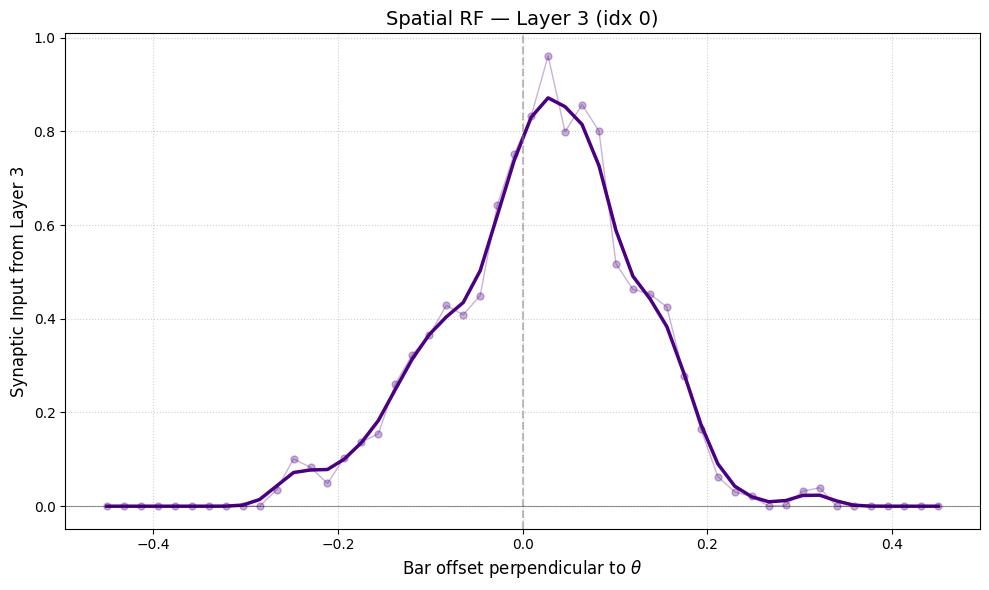

In [32]:
#############################
#   Bar Sweep RF: Layer 3   #
#############################

W_0 = (W_0_E + W_0_I).tocsr()
W_1 = (W_1_E + W_1_I).tocsr()

fwd = lambda a, W: np.asarray(a @ W).ravel()

target_x, target_y = 0.50, 0.50

target_idx = 0
theta_stim = l_vals_L3[target_idx, 2]

print(f"Index: {target_idx}")
print(f"Location: x={l_vals_L3[target_idx, 0]:.3f}, y={l_vals_L3[target_idx, 1]:.3f}")
print(f"Preferred Orientation: {np.degrees(l_vals_L3[target_idx, 2]):.1f}°\n")


n_steps   = 50
offsets   = np.linspace(-0.45, 0.45, n_steps)
thickness = sig_0_E * 2
length    = 0.25

n_ref = len(get_indices_in_line(xy_L0_E, theta_stim, thickness=thickness,
                               length=length, cx=target_x, cy=target_y)[0])

cell_inputs = []

for d in offsets:
    cx = target_x - d * np.sin(theta_stim)
    cy = target_y + d * np.cos(theta_stim)

    stim_indices, _, _ = get_indices_in_line(
        xy_L0_E, theta_stim, thickness=thickness, length=length, cx=cx, cy=cy
    )

    mask = np.zeros(N_L0_E)
    mask[stim_indices] = 1
    mask *= n_ref / max(mask.sum(), 1)

    A_0 = mask
    A_1 = fwd(ReLU(A_0), W_0)
    A_2 = fwd(ReLU(A_1), W_1)
    A_3 = fwd(ReLU(A_2), W_2_E)
    target_cell_input = A_3[target_idx]

    cell_inputs.append(target_cell_input)

cell_inputs = np.asarray(cell_inputs)
cell_inputs_smooth = gaussian_filter1d(cell_inputs, sigma=1.0, mode='nearest')

plt.figure(figsize=(10, 6))
plt.plot(offsets, cell_inputs, marker='o', ms=5, linestyle='-', color='indigo',
         linewidth=1, alpha=0.3)
plt.plot(offsets, cell_inputs_smooth, linestyle='-', color='indigo', linewidth=2.5)

plt.title(f'Spatial RF — Layer 3 (idx {target_idx})', fontsize=14)
plt.xlabel('Bar offset perpendicular to $\\theta$', fontsize=12)
plt.ylabel('Synaptic Input from Layer 3', fontsize=12)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(0, color='k', linewidth=0.8, alpha=0.4)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()